# Country Data Clusturing Analysis

# Imports

In [113]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans,DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

# Loading the Dataset

In [114]:
df=pd.read_csv('/content/Country-data.csv')
df=pd.DataFrame(df)

In [115]:
df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [116]:
print("Shape: ",df.shape)

Shape:  (167, 10)


# Understanding the data

In [117]:
print("Features: ",df.columns.tolist())

Features:  ['country', 'child_mort', 'exports', 'health', 'imports', 'income', 'inflation', 'life_expec', 'total_fer', 'gdpp']


In [118]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


In [119]:
df.describe()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000
mean,38.270060,41.108976,6.815689,46.890215,17144.688623,7.781832,70.555689,2.947964,12964.155689
std,40.328931,27.412010,2.746837,24.209589,19278.067698,10.570704,8.893172,1.513848,18328.704809
min,2.600000,0.109000,1.810000,0.065900,609.000000,-4.210000,32.100000,1.150000,231.000000
25%,8.250000,23.800000,4.920000,30.200000,3355.000000,1.810000,65.300000,1.795000,1330.000000
50%,19.300000,35.000000,6.320000,43.300000,9960.000000,5.390000,73.100000,2.410000,4660.000000
75%,62.100000,51.350000,8.600000,58.750000,22800.000000,10.750000,76.800000,3.880000,14050.000000
max,208.000000,200.000000,17.900000,174.000000,125000.000000,104.000000,82.800000,7.490000,105000.000000


In [120]:
print("No of null values")
print(df.isnull().sum())

No of null values
country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64


In [121]:
print("No of duplicated rows: ",df.duplicated().sum())

No of duplicated rows:  0


# Handling the data

In [122]:
data=df
data.columns=data.columns.str.strip()
data=data.drop_duplicates()
country_name=data['country']
data=data.drop('country',axis=1)
data=data.fillna(data.median())


Copied dataframe to data and dropped duplicate rows, made a seperated country from the data, and filled na with median values

# Correlation Analysis

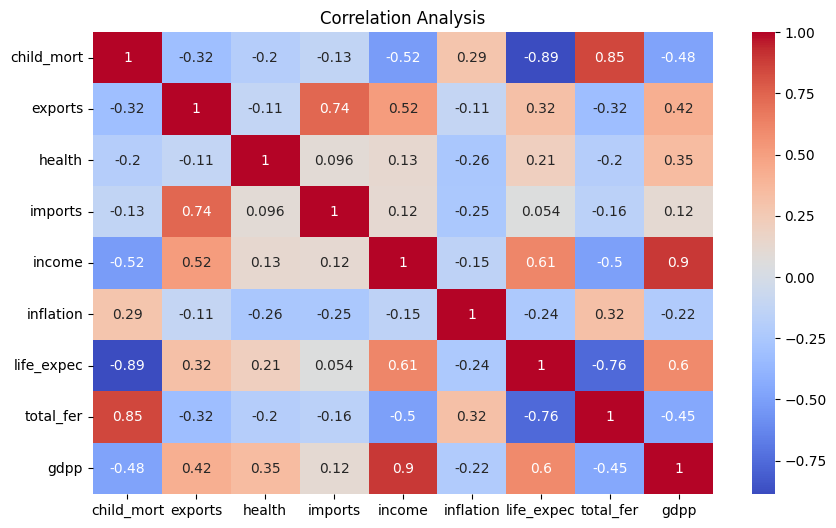

In [123]:
plt.figure(figsize=(10,6))
plt.title("Correlation Analysis")
corr=data.corr()
sns.heatmap(corr,annot=True,cmap='coolwarm')
plt.show()

From this we can say:
*  Income and GDP show strong positive correlation richer countries have higher GDP per capita.
*  Child mortality is negatively correlated with life expectancy  higher deaths in poorer countries.

# Feature Scaling

In [124]:
scaler=StandardScaler()
data_scaled=scaler.fit_transform(data)
df_scaled=pd.DataFrame(data_scaled,columns=data.columns)
df_scaled.head()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,1.291532,-1.138280,0.279088,-0.082455,-0.808245,0.157336,-1.619092,1.902882,-0.679180
1,-0.538949,-0.479658,-0.097016,0.070837,-0.375369,-0.312347,0.647866,-0.859973,-0.485623
2,-0.272833,-0.099122,-0.966073,-0.641762,-0.220844,0.789274,0.670423,-0.038404,-0.465376
3,2.007808,0.775381,-1.448071,-0.165315,-0.585043,1.387054,-1.179234,2.128151,-0.516268
4,-0.695634,0.160668,-0.286894,0.497568,0.101732,-0.601749,0.704258,-0.541946,-0.041817


# Elbow Method for KMeans

In [125]:
inertias=[]
k_values=range(2,11)
for i in range(2,11):
  kmeans=KMeans(n_clusters=i,random_state=42,n_init=10)
  kmeans.fit(df_scaled)
  inertias.append(kmeans.inertia_)
  print(f'Inertia for {i} clusters: {kmeans.inertia_}')

Inertia for 2 clusters: 1050.2145582853307
Inertia for 3 clusters: 831.424435208687
Inertia for 4 clusters: 700.52053697222
Inertia for 5 clusters: 620.163371288842
Inertia for 6 clusters: 558.4696598590399
Inertia for 7 clusters: 495.8079455215346
Inertia for 8 clusters: 457.5861478912421
Inertia for 9 clusters: 427.80367198134667
Inertia for 10 clusters: 403.2296125136434


# Line plot for Elbow Method to determine K value

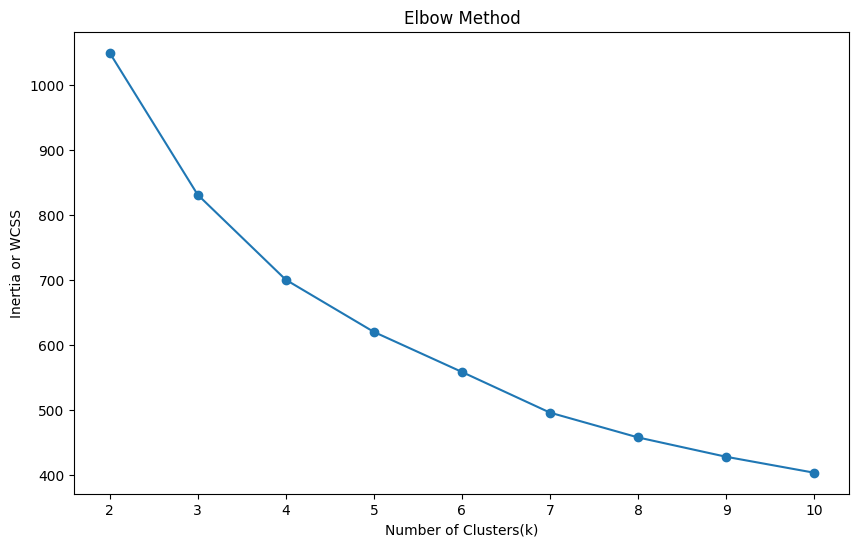

In [126]:
plt.figure(figsize=(10,6))
plt.plot(k_values,inertias,'-o')
plt.xlabel('Number of Clusters(k)')
plt.ylabel('Inertia or WCSS')
plt.title('Elbow Method')
plt.show()

Observation:


*   As the number of clusters is increasing the inertia or wcss value is decreasing.
*   At certain point the rate of decrease has slow down we determine that as elbow point and we consider its x-axis value as the k-value.
*   In the diagram that point is 3





#KMeans Model

In [127]:
kmeans=KMeans(n_clusters=3,random_state=42,n_init=10)
df['kmeans_Cluster']=kmeans.fit_predict(df_scaled)

In [128]:
df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,kmeans_Cluster
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553,1
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090,2
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460,2
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530,1
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200,2


In [129]:
df['kmeans_Cluster'].value_counts()

,count
kmeans_Cluster,
2,84
1,47
0,36


# Silhouette Score

In [130]:
score=silhouette_score(df_scaled,df['kmeans_Cluster'])
print("Silhouette Score: ",score)

Silhouette Score:  0.28329575683463126


# DBScan

In [131]:
dbscan=DBSCAN(eps=1.5,min_samples=5)
df['dbscan_Cluster']=dbscan.fit_predict(df_scaled)

In [132]:
df['dbscan_Cluster'].value_counts()

,count
dbscan_Cluster,
0,137
-1,30


# PCA

In [133]:
pca=PCA(n_components=2,random_state=42)
df_pca=pca.fit_transform(df_scaled)
pca_data = pd.DataFrame({'pca1': df_pca[:, 0],'pca2': df_pca[:, 1],'cluster': df['kmeans_Cluster']})

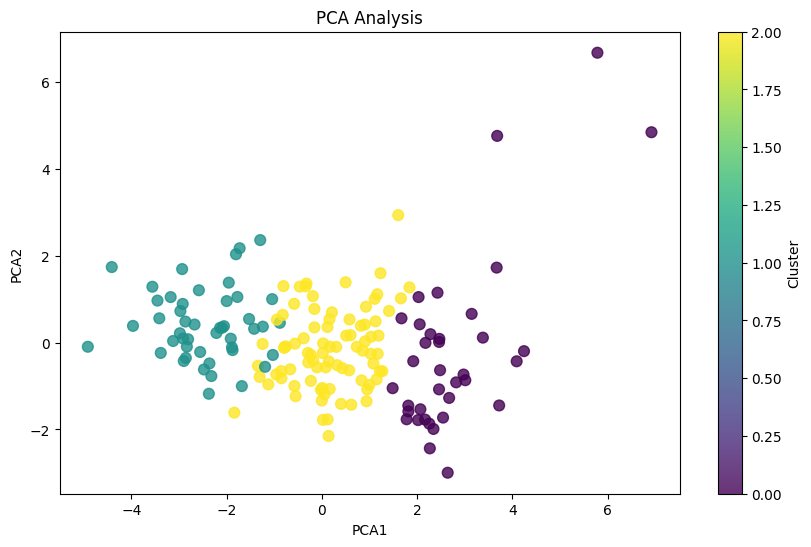

In [134]:
plt.figure(figsize=(10,6))
scatter = plt.scatter(pca_data["pca1"],pca_data["pca2"],c=pca_data["cluster"],cmap="viridis",s=60,alpha=0.8)
plt.xlabel("PCA1")
plt.ylabel("PCA2")
plt.title("PCA Analysis")
plt.colorbar(scatter, label="Cluster")
plt.show()

# Clusters Summary

In [135]:
profile = (df.drop(columns=['dbscan_Cluster']).groupby('kmeans_Cluster').mean(numeric_only=True).round(2))
profile

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
kmeans_Cluster,,,,,,,,,
0,5.00,58.74,8.81,51.49,45672.22,2.67,80.13,1.75,42494.44
1,92.96,29.15,6.39,42.32,3942.40,12.02,59.19,5.01,1922.38
2,21.93,40.24,6.20,47.47,12305.60,7.60,72.81,2.31,6486.45


From this we can say that
* cluster 0 are Developed Countries
* Cluster 1 are UnderDeveloped Countries
* Cluster 2 are Developing Countries

In [136]:
coun=['Developed','UnderDeveloped','Developing']
for c in sorted(df["kmeans_Cluster"].unique()):
    print(coun[c]," Counntries")
    print(df[df["kmeans_Cluster"] == c]["country"].head(15).tolist())
    print()

Developed  Counntries
['Australia', 'Austria', 'Bahrain', 'Belgium', 'Brunei', 'Canada', 'Cyprus', 'Czech Republic', 'Denmark', 'Finland', 'France', 'Germany', 'Greece', 'Iceland', 'Ireland']

UnderDeveloped  Counntries
['Afghanistan', 'Angola', 'Benin', 'Botswana', 'Burkina Faso', 'Burundi', 'Cameroon', 'Central African Republic', 'Chad', 'Comoros', 'Congo, Dem. Rep.', 'Congo, Rep.', "Cote d'Ivoire", 'Equatorial Guinea', 'Eritrea']

Developing  Counntries
['Albania', 'Algeria', 'Antigua and Barbuda', 'Argentina', 'Armenia', 'Azerbaijan', 'Bahamas', 'Bangladesh', 'Barbados', 'Belarus', 'Belize', 'Bhutan', 'Bolivia', 'Bosnia and Herzegovina', 'Brazil']



# Final Insights



*   UnderDeveloped Countires (i.e.Cluster 1) has high child mortality rate.
*   Developed Countries (i.e. Cluster 0) has High income and gdpp as they are highly corelated an increase in income is generally associated with an increase in GDPP
*  Cluster 1 looks under-developed beacuse it has low gdpp, low life expectancy, high inflation, least import and export rate and least healthcare
*  UnderDeveloped Countires(i.e. Cluster 1) should prioritize the aid.



